# SMF 05 · Quiescent fraction vs. stellar mass: cluster radial bins and field

f_q = φ_quiescent / φ_total from the three radial-bin runs of `02a` compared with the count-based field quiescent fraction (`FieldSMF_fq_Dn4000.csv`), Figure 16.

**Inputs**: `SMF_results/MACH_total_Rbin_*.npz`, `../../FIELD/FieldSMF_fq_Dn4000.csv`, `DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv` (not included)

**Output**: `FIGURE/IMAGES/Figure16.pdf`

In [2]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

In [3]:
# Load MACH master catalog
mach_path = f"{MAINPATH}/DATA/MACH_MASS/MACH_DR18_3R200_mastercat.csv"
mach_data = pd.read_csv(mach_path)

# Correct cmodel magnitudes for extinction
for band in ("g", "r"):
    mach_data[f"cmodelMag_{band}_0"] = (
        mach_data[f"cmodelMag_{band}"] - mach_data[f"extinction_{band}"]
    )

# Load HeCS VAC catalog
hecs_vac_path = f"{MAINPATH}/DATA/MACH_PHOT/AllHeCS_VAC_updated.csv"
hecs_vac_data = pd.read_csv(hecs_vac_path)

df = mach_data.copy()

In [4]:
df = df[df['MEMBER']=='Y']

# Quiescent fraction (Figure 16)

In [5]:
# =============================================================
# Load saved results (use this in another notebook/session to plot)
# =============================================================

def load_mach_total_results(path='MACH_total_results.npz'):
    """Load .npz and return the same structure as `result` (for plotting)."""
    d = np.load(path, allow_pickle=True)
    fit_labels = list(d['fit_labels'])
    fit_results = {
        lbl: (d['fit_median'][i], d['fit_lower'][i], d['fit_upper'][i])
        for i, lbl in enumerate(fit_labels)
    }
    return {
        'mean_all': d['mean_all'],
        'mean_quenched': d['mean_quenched'],
        'mean_sf': d['mean_sf'],
        'original_counts': d['original_counts'],
        'bin_centers': d['bin_centers'],
        'complim': float(d['complim']),
        'fit_results': fit_results,
    }

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72060/202082837.py:47: RuntimeWarning: invalid value encountered in divide
  fq  = np.where(valid, nq / na, 0.0)


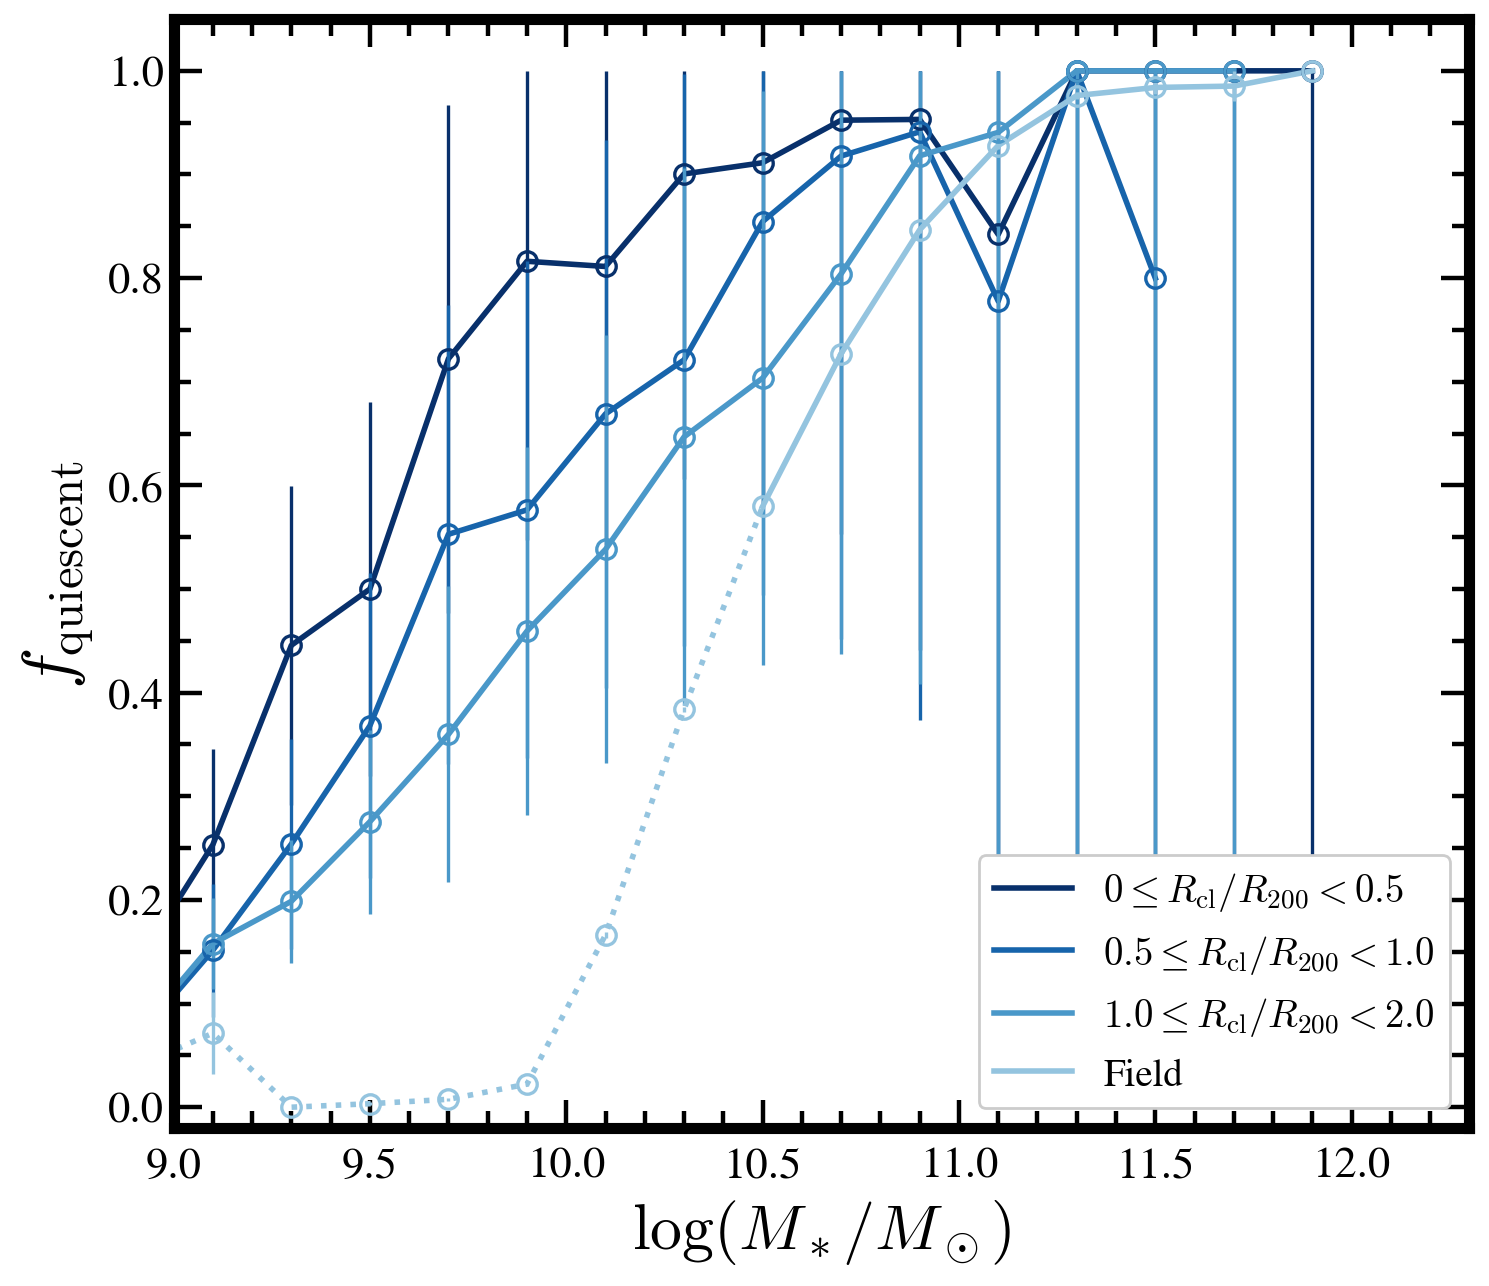

In [6]:
# =============================================================
# Uses load_mach_total_results() defined in the cell above.
# =============================================================

# =============================================================
# Configuration
# =============================================================
FIELD_CSV        = f'{MAINPATH}/CODE/FIELD/FieldSMF_fq_Dn4000.csv'
FIELD_MASS_LIMIT = 10.538    # field completeness limit [log M*]

# Radial-bin .npz files and their panel annotations
cluster_files = [
    ('./SMF_results/MACH_total_Rbin_0p0to0p5R200.npz',
     r'$0 \leq R_\mathrm{cl}/R_{200} < 0.5$'),
    ('./SMF_results/MACH_total_Rbin_0p5to1p0R200.npz',
     r'$0.5 \leq R_\mathrm{cl}/R_{200} < 1.0$'),
    ('./SMF_results/MACH_total_Rbin_1p0to2p0R200.npz',
     r'$1.0 \leq R_\mathrm{cl}/R_{200} < 2.0$'),
]

# Colour sequence: darker blue = inner, lighter blue = outer, faintest = field
cmap   = plt.get_cmap('Blues')
colors = [cmap(1.0), cmap(0.8), cmap(0.6), cmap(0.4)]

# =============================================================
# Plot
# =============================================================
fig, ax = plt.subplots(figsize=(8, 7))

# ------------------------------------------------------------------
# Cluster radial panels  (loaded from .npz)
# ------------------------------------------------------------------
for (path, label), color in zip(cluster_files, colors[:3]):
    res = load_mach_total_results(path)

    bc = np.asarray(res['bin_centers'])
    na = np.asarray(res['mean_all'])
    nq = np.asarray(res['mean_quenched'])

    # Quenched fraction and Poisson propagated error
    valid = (na > 0) & (nq > 0)
    fq  = np.where(valid, nq / na, 0.0)
    err = np.where(valid, fq * np.sqrt(1.0 / na.clip(1) + 1.0 / nq.clip(1)), 0.0)

    # Clamp asymmetric errors within [0, 1]
    lo = np.where(valid, np.minimum(err, fq),       0.0)
    hi = np.where(valid, np.minimum(err, 1.0 - fq), 0.0)

    ax.errorbar(
        bc[valid], fq[valid], yerr=[lo[valid], hi[valid]],
        fmt='o', color=color, ecolor=color,
        markerfacecolor='none', markeredgewidth=1.2, markersize=7,
        elinewidth=1.2, capsize=0
    )
    ax.plot(bc[valid], fq[valid],
            linestyle='-', linewidth=2, color=color, label=label)

# ------------------------------------------------------------------
# Field panel  (loaded from CSV)
# ------------------------------------------------------------------
df_field = pd.read_csv(FIELD_CSV)

x_all  = np.asarray(df_field['logM'])
fq_all = np.asarray(df_field['f_q'])
el_all = np.asarray(df_field.get('f_q_err_low',  pd.Series(np.zeros(len(df_field)))))
eh_all = np.asarray(df_field.get('f_q_err_high', pd.Series(np.zeros(len(df_field)))))

# Keep finite rows, sort by mass
valid = np.isfinite(fq_all) & np.isfinite(x_all)
x  = x_all[valid];  fq = np.clip(fq_all[valid], 0.0, 1.0)
el = np.minimum(el_all[valid], fq);  eh = np.minimum(eh_all[valid], 1.0 - fq)
order  = np.argsort(x)
x, fq, el, eh = x[order], fq[order], el[order], eh[order]

m_below = x <  FIELD_MASS_LIMIT
m_above = x >= FIELD_MASS_LIMIT
color_field = colors[3]

# Below completeness limit: dotted line, hollow markers (no label)
if np.any(m_below):
    ax.errorbar(
        x[m_below], fq[m_below], yerr=[el[m_below], eh[m_below]],
        fmt='o', color=color_field, ecolor=color_field,
        markerfacecolor='none', markeredgewidth=1.2, markersize=7,
        elinewidth=1.2, capsize=0
    )
    ax.plot(x[m_below], fq[m_below],
            linestyle=':', linewidth=2, color=color_field)

# Above completeness limit: solid line + label
if np.any(m_above):
    ax.errorbar(
        x[m_above], fq[m_above], yerr=[el[m_above], eh[m_above]],
        fmt='o', color=color_field, ecolor=color_field,
        markerfacecolor='none', markeredgewidth=1.2, markersize=7,
        elinewidth=1.2, capsize=0
    )
    ax.plot(x[m_above], fq[m_above],
            linestyle='-', linewidth=2, color=color_field, label='Field')

# Solid bridge connecting last-below point to first-above point
if np.any(m_below) and np.any(m_above):
    i_b = np.where(m_below)[0][-1]
    i_a = np.where(m_above)[0][0]
    ax.plot([x[i_b], x[i_a]], [fq[i_b], fq[i_a]],
            linestyle='-', linewidth=2, color=color_field)

# =============================================================
# Axes style
# =============================================================
ax.set_xlim(9, 12.3)
ax.set_ylim(-0.02, 1.05)
ax.set_xlabel(r'$\log(M_*/M_\odot)$', fontsize=23)
ax.set_ylabel(r'$f_{\rm quiescent}$', fontsize=25)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.minorticks_on()
ax.tick_params(which='both', direction='in', top=True, right=True)
ax.legend(fontsize=14, frameon=True, framealpha=1.0)

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure16.pdf",
            format='pdf', dpi=150, bbox_inches='tight')
plt.show()